# Picoclimate Hierarchy EDA

This notebook explores the browseable Picoclimate fixture stored under `data/picoclimate_test/cities/`.

The layout is:

`city -> date -> slot -> track`

Each track leaf is a matrix where rows are variables and columns are `location_id` values.

The focus here is on:

- distributions of the measured variables
- missing data at the file, variable, slot, date, and city levels
- location coverage across the track matrices
- hierarchy-aware comparisons across cities and dates

In [2]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.9)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

ROOT = Path('..') / 'data' / 'picoclimate_test'
CITY_ROOT = ROOT / 'cities'
OUTPUT_DIR = Path('outputs') / 'picoclimate_hierarchy_eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALUE_COLUMNS = [
    'air_temp_c', 'rel_humidity_pct', 'wind_speed_ms', 'wind_dir_deg', 'pressure_hpa',
    'precipitation_mm', 'solar_wm2', 'longwave_wm2', 'surface_temp_c', 'soil_moisture_pct',
    'ndvi', 'pm25_ugm3', 'pm10_ugm3', 'co2_ppm', 'no2_ppb', 'o3_ppb', 'noise_db',
    'traffic_index', 'pedestrian_index', 'sky_view_factor', 'impervious_fraction',
    'water_proximity', 'heat_index_c',
]

print('City root:', CITY_ROOT.resolve())
print('Output dir:', OUTPUT_DIR.resolve())

City root: D:\repositories\personal\xai-spatio-temporal\data\picoclimate_test\cities
Output dir: D:\repositories\personal\xai-spatio-temporal\notebooks\outputs\picoclimate_hierarchy_eda


In [3]:
def discover_leaf_files(city_root: Path) -> pd.DataFrame:
    records = []
    for csv_path in sorted(city_root.glob('*/*/*/*.csv')):
        parts = csv_path.relative_to(city_root).parts
        if len(parts) != 4:
            continue
        city, date, time_slot, track_file = parts
        track_id = Path(track_file).stem
        records.append({
            'city': city,
            'date': date,
            'time_slot': time_slot,
            'track_id': track_id,
            'path': csv_path,
        })
    return pd.DataFrame(records)

def load_track_matrix(record: pd.Series) -> tuple[pd.DataFrame, dict]:
    frame = pd.read_csv(record['path'], low_memory=False)
    if 'variable' not in frame.columns:
        raise ValueError(f"Missing variable column in {record['path']}")

    location_columns = [column for column in frame.columns if column != 'variable']
    variable_order = frame['variable'].tolist()

    long_frame = frame.melt(id_vars='variable', var_name='location_id', value_name='value')
    long_frame['city'] = record['city']
    long_frame['date'] = record['date']
    long_frame['time_slot'] = record['time_slot']
    long_frame['track_id'] = record['track_id']
    long_frame['variable_rank'] = long_frame['variable'].map({name: idx for idx, name in enumerate(variable_order)})
    long_frame['location_rank'] = long_frame['location_id'].map({name: idx for idx, name in enumerate(location_columns)})
    long_frame['value'] = pd.to_numeric(long_frame['value'], errors='coerce')

    summary = {
        'city': record['city'],
        'date': record['date'],
        'time_slot': record['time_slot'],
        'track_id': record['track_id'],
        'path': str(record['path']),
        'n_variables': len(variable_order),
        'n_locations': len(location_columns),
        'n_cells': int(len(variable_order) * len(location_columns)),
        'observed_cells': int(long_frame['value'].notna().sum()),
        'missing_cells': int(long_frame['value'].isna().sum()),
        'missing_rate': float(long_frame['value'].isna().mean()),
    }
    return long_frame, summary

leaf_inventory = discover_leaf_files(CITY_ROOT)
leaf_inventory.head()

,city,date,time_slot,track_id,path
0,Montpellier,2026-05-01,afternoon,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...
1,Montpellier,2026-05-01,morning,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...
2,Montpellier,2026-05-01,morning,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...
3,Montpellier,2026-05-01,night,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...
4,Montpellier,2026-05-01,noon,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...


In [4]:
leaf_summaries = []
long_frames = []

for record in leaf_inventory.to_dict('records'):
    long_frame, summary = load_track_matrix(pd.Series(record))
    long_frames.append(long_frame)
    leaf_summaries.append(summary)

track_long = pd.concat(long_frames, ignore_index=True)
leaf_summary = pd.DataFrame(leaf_summaries)

print('Leaf files:', len(leaf_summary))
print('Long table shape:', track_long.shape)
print('Overall missing rate:', round(track_long['value'].isna().mean(), 4))
leaf_summary.sort_values(['city', 'date', 'time_slot', 'track_id']).head(10)

Leaf files: 386
Long table shape: (890169, 9)
Overall missing rate: 0.0513


,city,date,time_slot,track_id,path,n_variables,n_locations,n_cells,observed_cells,missing_cells,missing_rate
0,Montpellier,2026-05-01,afternoon,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,104,2392,2231,161,0.067308
1,Montpellier,2026-05-01,morning,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,106,2438,2277,161,0.066038
2,Montpellier,2026-05-01,morning,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,106,2438,2346,92,0.037736
3,Montpellier,2026-05-01,night,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,105,2415,2277,138,0.057143
4,Montpellier,2026-05-01,noon,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,104,2392,2346,46,0.019231
5,Montpellier,2026-05-01,noon,mon_track_004,..\data\picoclimate_test\cities\Montpellier\20...,23,99,2277,2162,115,0.050505
6,Montpellier,2026-05-01,noon,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,106,2438,2415,23,0.009434
7,Montpellier,2026-05-02,morning,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,98,2254,2162,92,0.040816
8,Montpellier,2026-05-02,morning,mon_track_004,..\data\picoclimate_test\cities\Montpellier\20...,23,101,2323,2231,92,0.039604
9,Montpellier,2026-05-02,night,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,106,2438,2231,207,0.084906


In [4]:
hierarchy_summary = (
    leaf_summary
    .groupby(['city', 'date', 'time_slot'], sort=True)
    .agg(
        n_tracks=('track_id', 'nunique'),
        n_files=('path', 'count'),
        avg_locations=('n_locations', 'mean'),
        avg_missing_rate=('missing_rate', 'mean'),
        min_missing_rate=('missing_rate', 'min'),
        max_missing_rate=('missing_rate', 'max'),
    )
    .reset_index()
)

city_summary = (
    leaf_summary
    .groupby('city', sort=True)
    .agg(
        tracks=('track_id', 'nunique'),
        dates=('date', 'nunique'),
        slots=('time_slot', 'nunique'),
        avg_locations=('n_locations', 'mean'),
        avg_missing_rate=('missing_rate', 'mean'),
        total_cells=('n_cells', 'sum'),
        observed_cells=('observed_cells', 'sum'),
    )
    .reset_index()
)
city_summary['overall_missing_rate'] = 1 - (city_summary['observed_cells'] / city_summary['total_cells'])

display(city_summary)
display(hierarchy_summary.head(20))

,city,tracks,dates,slots,avg_locations,avg_missing_rate,total_cells,observed_cells,overall_missing_rate
0,Montpellier,6,20,4,99.929134,0.050983,291893,276989,0.051060
1,Nantes,10,21,4,100.432432,0.051419,598276,567525,0.051399


,city,date,time_slot,n_tracks,n_files,avg_locations,avg_missing_rate,min_missing_rate,max_missing_rate
0,Montpellier,2026-05-01,afternoon,1,1,104.000000,0.067308,0.067308,0.067308
1,Montpellier,2026-05-01,morning,2,2,106.000000,0.051887,0.037736,0.066038
2,Montpellier,2026-05-01,night,1,1,105.000000,0.057143,0.057143,0.057143
3,Montpellier,2026-05-01,noon,3,3,103.000000,0.026390,0.009434,0.050505
4,Montpellier,2026-05-02,morning,2,2,99.500000,0.040210,0.039604,0.040816
5,Montpellier,2026-05-02,night,1,1,106.000000,0.084906,0.084906,0.084906
6,Montpellier,2026-05-02,noon,1,1,104.000000,0.067308,0.067308,0.067308
7,Montpellier,2026-05-04,afternoon,1,1,102.000000,0.049020,0.049020,0.049020
8,Montpellier,2026-05-04,morning,2,2,99.000000,0.040404,0.040404,0.040404
9,Montpellier,2026-05-04,night,3,3,96.000000,0.041676,0.030612,0.062500


,observed,mean,std,min,median,max,missing_rate
variable,,,,,,,
air_temp_c,36718,20.414421,4.074963,9.103455,20.692091,31.779402,0.958752
co2_ppm,36718,422.508870,23.413201,354.269692,424.218467,485.764834,0.958752
heat_index_c,36718,22.207365,4.584232,9.929863,22.624096,34.278604,0.958752
impervious_fraction,36718,0.608767,0.086735,0.329695,0.612188,0.889020,0.958752
longwave_wm2,36718,356.665906,59.886693,200.000000,362.229576,494.376572,0.958752
ndvi,36718,0.530091,0.153856,0.108872,0.542488,0.898453,0.958752
no2_ppb,36718,25.854980,8.639671,0.000000,26.214965,51.435739,0.958752
noise_db,36718,55.660798,6.351212,36.983583,56.130827,73.649390,0.958752
o3_ppb,36718,61.222968,12.183312,23.414492,61.992752,96.806416,0.958752


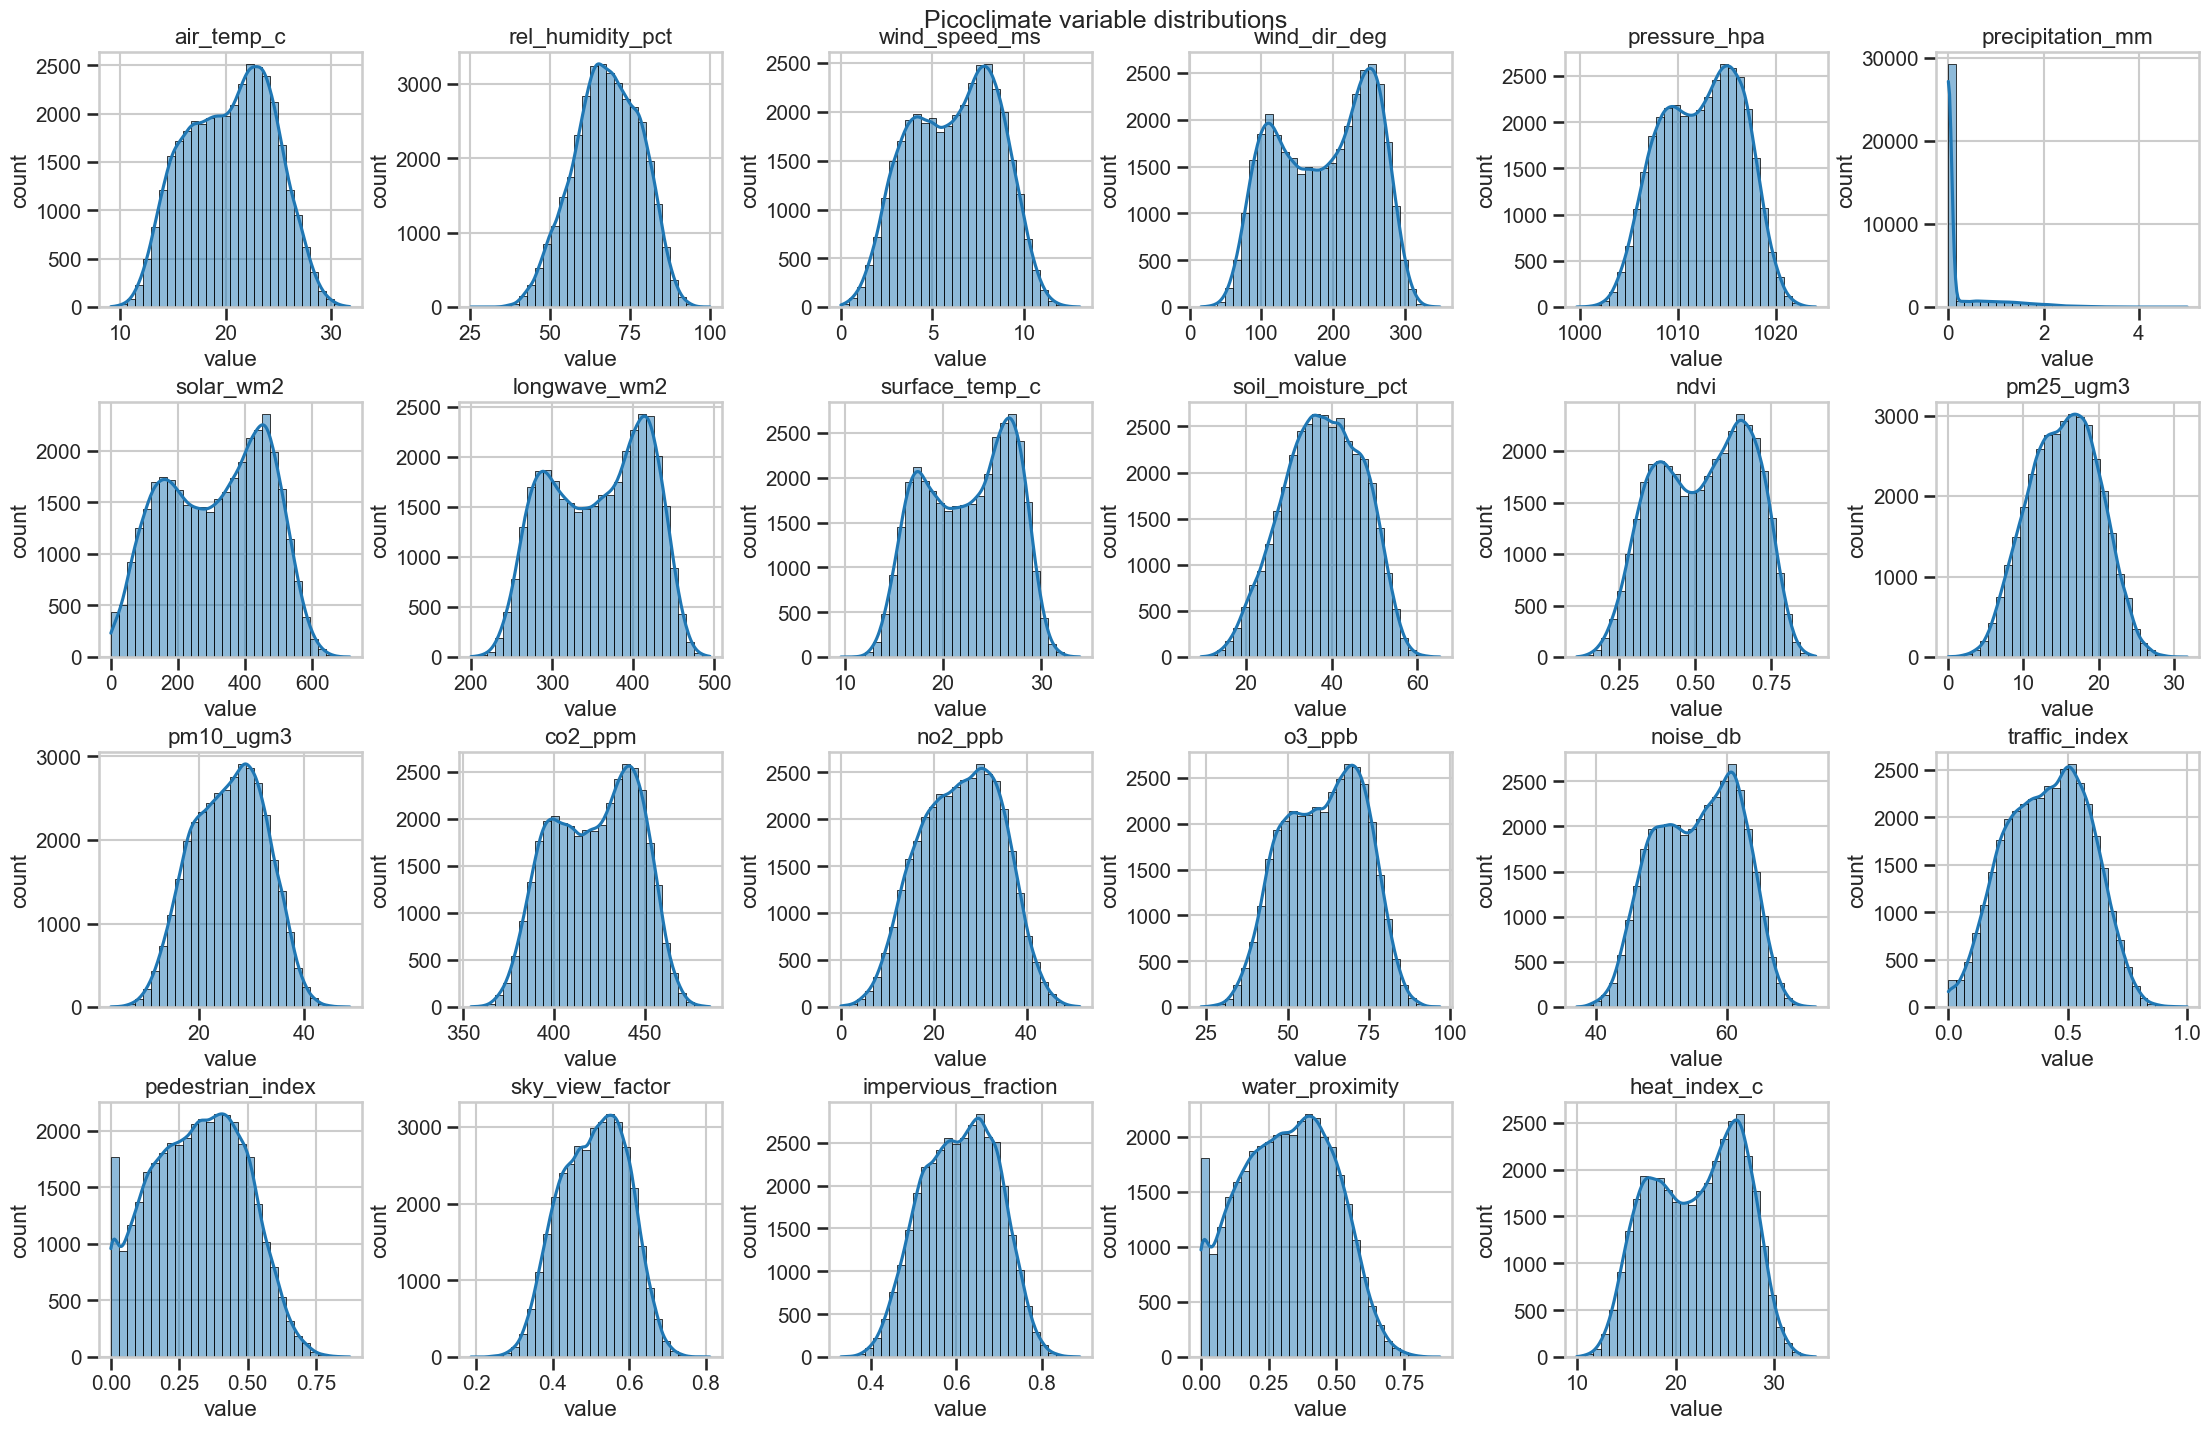

In [5]:
variable_summary = (
    track_long
    .groupby('variable', sort=True)['value']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .rename(columns={'count': 'observed'})
    .assign(missing_rate=lambda frame: 1 - frame['observed'] / len(track_long))
    .sort_values('missing_rate', ascending=False)
)

display(variable_summary)

fig, axes = plt.subplots(4, 6, figsize=(22, 14), constrained_layout=True)
axes = axes.ravel()
for axis, variable in zip(axes, VALUE_COLUMNS):
    values = track_long.loc[track_long['variable'] == variable, 'value'].dropna()
    if values.empty:
        axis.set_title(f'{variable} (all missing)')
        axis.axis('off')
        continue
    sns.histplot(values, bins=30, kde=True, ax=axis, color='#1f77b4')
    axis.set_title(variable)
    axis.set_xlabel('value')
    axis.set_ylabel('count')
for axis in axes[len(VALUE_COLUMNS):]:
    axis.axis('off')
fig.suptitle('Picoclimate variable distributions', y=1.01, fontsize=18)
fig.savefig(OUTPUT_DIR / 'variable_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

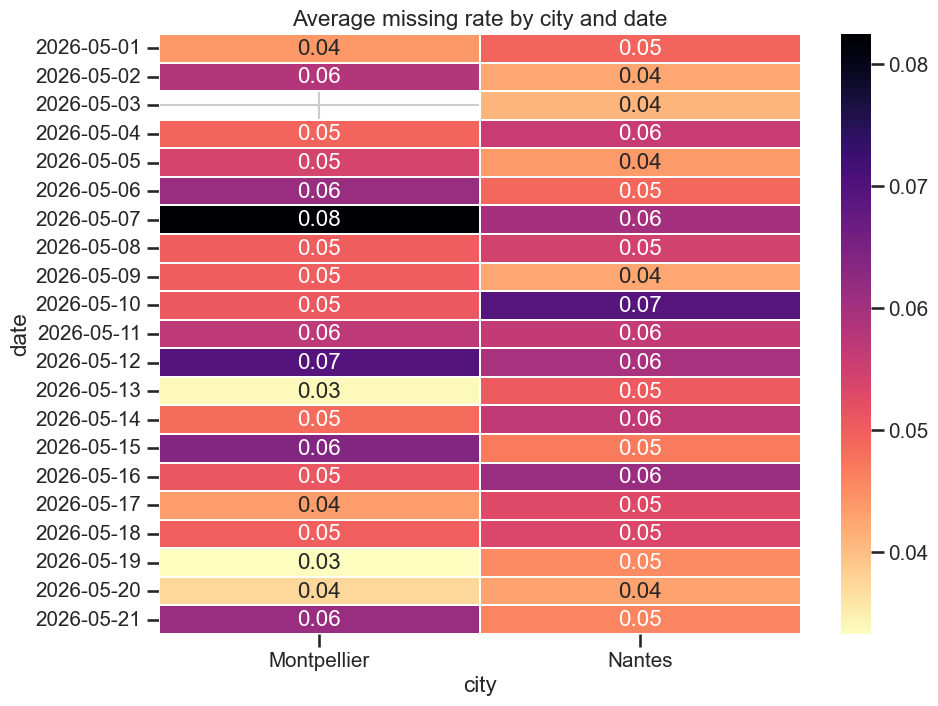

,city,time_slot,avg_missing_rate,avg_locations,tracks
0,Montpellier,afternoon,0.037006,100.041667,6
1,Montpellier,morning,0.055496,100.866667,6
2,Montpellier,night,0.056035,98.735294,6
3,Montpellier,noon,0.051709,100.179487,6
4,Nantes,afternoon,0.053021,101.112676,10
5,Nantes,morning,0.047094,100.333333,10
6,Nantes,night,0.054630,100.032787,10
7,Nantes,noon,0.050838,100.156250,10


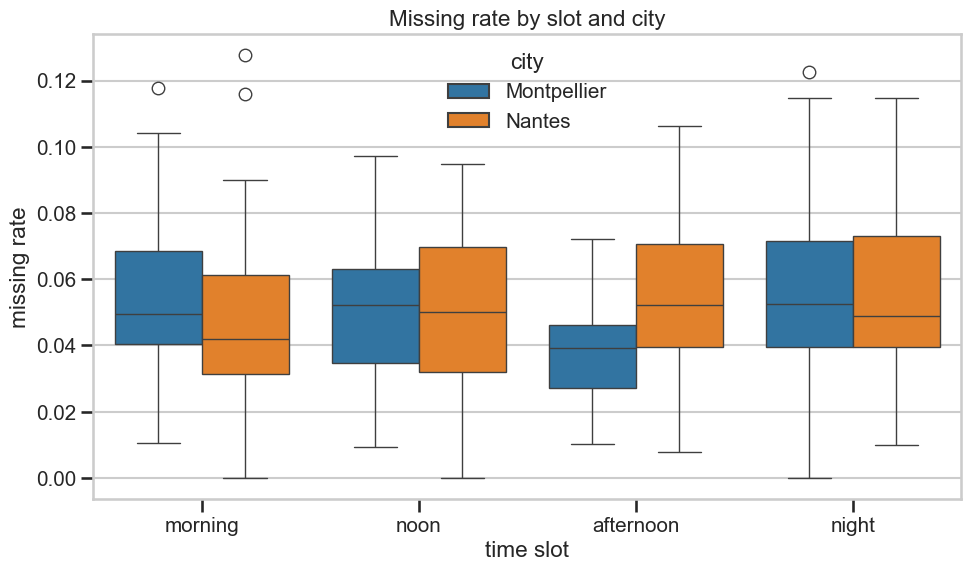

In [6]:
date_missing = (
    leaf_summary
    .groupby(['city', 'date'], sort=True)
    .agg(avg_missing_rate=('missing_rate', 'mean'), files=('path', 'count'), locations=('n_locations', 'mean'))
    .reset_index()
)

pivot_missing = date_missing.pivot(index='date', columns='city', values='avg_missing_rate').sort_index()
plt.figure(figsize=(10, max(6, 0.35 * len(pivot_missing))))
sns.heatmap(pivot_missing, cmap='magma_r', linewidths=0.3, linecolor='white', annot=True, fmt='.2f')
plt.title('Average missing rate by city and date')
plt.xlabel('city')
plt.ylabel('date')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'missing_rate_by_city_date.png', dpi=160, bbox_inches='tight')
plt.show()

slot_missing = (
    leaf_summary
    .groupby(['city', 'time_slot'], sort=True)
    .agg(avg_missing_rate=('missing_rate', 'mean'), avg_locations=('n_locations', 'mean'), tracks=('track_id', 'nunique'))
    .reset_index()
)
display(slot_missing)

plt.figure(figsize=(10, 6))
sns.boxplot(data=leaf_summary, x='time_slot', y='missing_rate', hue='city', order=['morning', 'noon', 'afternoon', 'night'])
plt.title('Missing rate by slot and city')
plt.xlabel('time slot')
plt.ylabel('missing rate')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'missing_rate_by_slot_city.png', dpi=160, bbox_inches='tight')
plt.show()

,city,date,time_slot,track_id,path,n_variables,n_locations,missing_rate
0,Montpellier,2026-05-01,afternoon,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,104,0.067308
1,Montpellier,2026-05-01,morning,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,106,0.066038
2,Montpellier,2026-05-01,morning,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,106,0.037736
3,Montpellier,2026-05-01,night,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,105,0.057143
4,Montpellier,2026-05-01,noon,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,104,0.019231
5,Montpellier,2026-05-01,noon,mon_track_004,..\data\picoclimate_test\cities\Montpellier\20...,23,99,0.050505
6,Montpellier,2026-05-01,noon,mon_track_005,..\data\picoclimate_test\cities\Montpellier\20...,23,106,0.009434
7,Montpellier,2026-05-02,morning,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,98,0.040816
8,Montpellier,2026-05-02,morning,mon_track_004,..\data\picoclimate_test\cities\Montpellier\20...,23,101,0.039604
9,Montpellier,2026-05-02,night,mon_track_002,..\data\picoclimate_test\cities\Montpellier\20...,23,106,0.084906


,city,date,time_slot,track_id,n_variables,n_locations,missing_rate,matrix_cells
count,386,386,386,386,386.0,386.000000,386.000000,386.000000
unique,2,21,4,16,NaN,NaN,NaN,NaN
top,Nantes,2026-05-18,noon,nan_track_008,NaN,NaN,NaN,NaN
freq,259,40,103,38,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,23.0,100.266839,0.051276,2306.137306
std,NaN,NaN,NaN,NaN,0.0,8.548337,0.023295,196.611752
min,NaN,NaN,NaN,NaN,23.0,87.000000,0.000000,2001.000000
25%,NaN,NaN,NaN,NaN,23.0,95.000000,0.032883,2185.000000
50%,NaN,NaN,NaN,NaN,23.0,98.000000,0.049020,2254.000000
75%,NaN,NaN,NaN,NaN,23.0,102.000000,0.068627,2346.000000


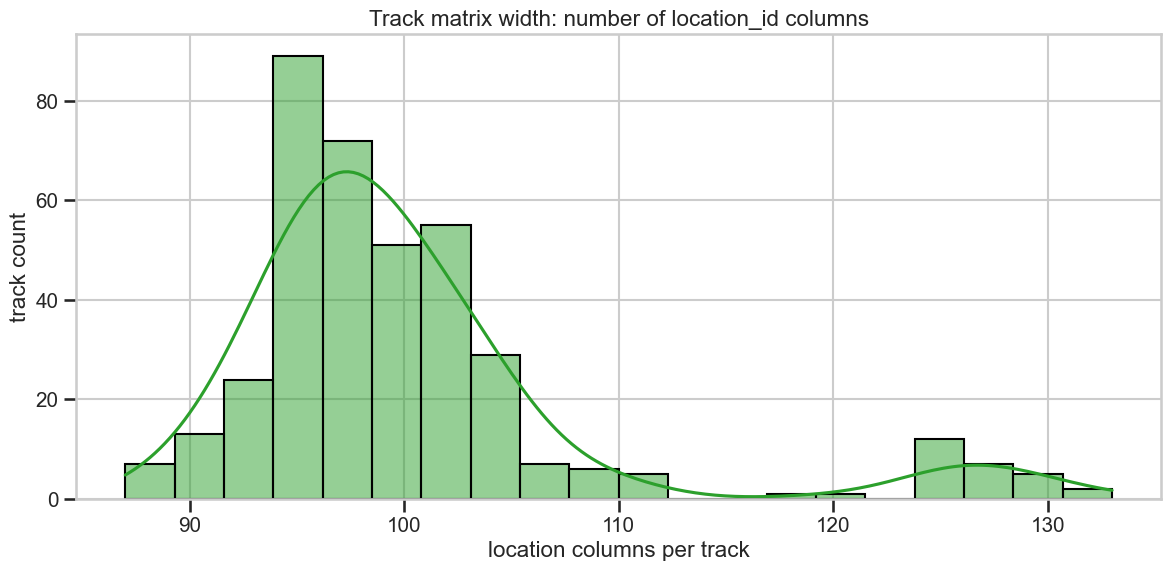

NameError: name 'loc_coverage' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
loc_coverage = (
    track_long
    .groupby('location_id', sort=True)['value']
    .agg(total='size', observed='count', mean='mean', median='median')
    .assign(missing_rate=lambda frame: 1 - frame['observed'] / frame['total'])
    .sort_values('missing_rate', ascending=False)
)

display(loc_coverage.head(20))

coverage_counts = (
    leaf_summary
    [['city', 'date', 'time_slot', 'track_id', 'path', 'n_variables', 'n_locations', 'missing_rate']]
    .sort_values(['city', 'date', 'time_slot', 'track_id'])
)

display(coverage_counts.head(20))

track_shape = leaf_summary[['city', 'date', 'time_slot', 'track_id', 'n_variables', 'n_locations', 'missing_rate']].copy()
track_shape['matrix_cells'] = track_shape['n_variables'] * track_shape['n_locations']
display(track_shape.describe(include='all'))

plt.figure(figsize=(12, 6))
sns.histplot(leaf_summary['n_locations'], bins=20, kde=True, color='#2ca02c')
plt.title('Track matrix width: number of location_id columns')
plt.xlabel('location columns per track')
plt.ylabel('track count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'track_matrix_width_hist.png', dpi=160, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(loc_coverage['missing_rate'], bins=20, kde=True, color='#d62728')
plt.title('Location coverage across all track matrices')
plt.xlabel('missing rate by location_id')
plt.ylabel('location count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'location_missing_rate_hist.png', dpi=160, bbox_inches='tight')
plt.show()

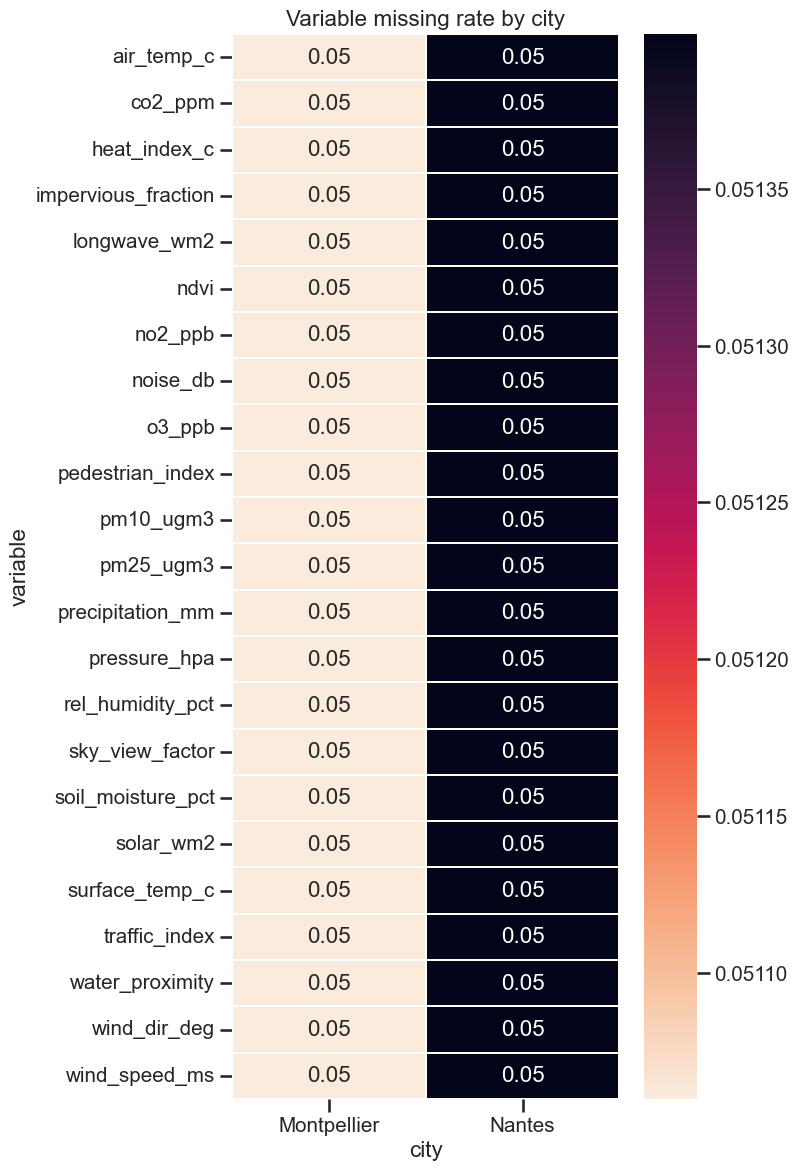

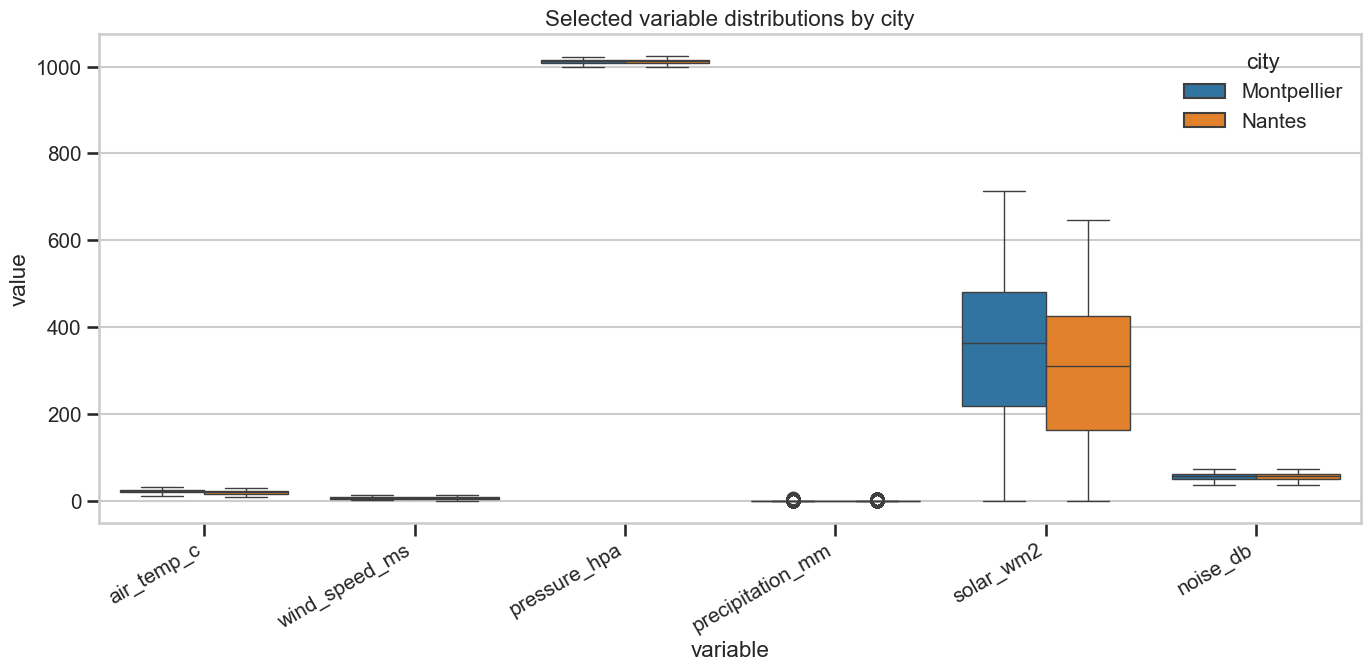

In [8]:
city_variable_missing = (
    track_long
    .groupby(['city', 'variable'], sort=True)['value']
    .apply(lambda series: 1 - series.notna().mean())
    .reset_index(name='missing_rate')
)

pivot_city_variable = city_variable_missing.pivot(index='variable', columns='city', values='missing_rate').sort_index()
plt.figure(figsize=(8, 12))
sns.heatmap(pivot_city_variable, cmap='rocket_r', annot=True, fmt='.2f', linewidths=0.3, linecolor='white')
plt.title('Variable missing rate by city')
plt.xlabel('city')
plt.ylabel('variable')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'variable_missing_rate_by_city.png', dpi=160, bbox_inches='tight')
plt.show()

sample_vars = ['air_temp_c', 'noise_db', 'wind_speed_ms', 'pressure_hpa', 'precipitation_mm', 'solar_wm2']
sample_df = track_long[track_long['variable'].isin(sample_vars) & track_long['value'].notna()].copy()
plt.figure(figsize=(14, 7))
sns.boxplot(data=sample_df, x='variable', y='value', hue='city')
plt.title('Selected variable distributions by city')
plt.xlabel('variable')
plt.ylabel('value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selected_variable_boxplots_by_city.png', dpi=160, bbox_inches='tight')
plt.show()

## What to look at next

The notebook now gives you a hierarchy-aware view of the fixture. The most useful outputs are:

- `city_summary` for city-level coverage
- `hierarchy_summary` for city/date/slot behavior
- `variable_summary` for distribution and missingness by variable
- `loc_coverage` for how complete the `location_id` columns are across tracks

All figures are also saved under `notebooks/outputs/picoclimate_hierarchy_eda/`.